# Pareto optimization of strength and toughness

Identifies the designs of the binary Bar–Y superlattice that trade off tensile strength against toughness, using the trained surrogates:

* `models/gpc_classifier.joblib` (from `configuration_type_classification.ipynb`) excludes designs that are predicted to form an expanded configuration, for which no property is predicted.
* `models/nn_ensemble/` (from `mechanical_property_prediction.ipynb`) predicts strength and toughness with a calibrated uncertainty $\hat\sigma_{\mathrm{cal}}$.

Because the design space is two-dimensional and the surrogates are cheap to evaluate, the Pareto sets are obtained by an exhaustive grid search over $L_{0,\mathrm{Bar}} \in [1, 2]$ cm and $L_{0,\mathrm{Y}} \in [1, 2.5]$ cm discretised at 0.02 cm. Rather than optimising the predicted means directly, the lower confidence bound $\hat\mu - \kappa\hat\sigma_{\mathrm{cal}}$ of each property is optimised, which the true value exceeds with probability $\Phi(\kappa)$:

$$P_\kappa = \{\mathbf{x} \in \mathcal{D} : \nexists\, \mathbf{x}' \in \mathcal{D} \text{ with } \hat\mu(\mathbf{x}') - \kappa\hat\sigma_{\mathrm{cal}}(\mathbf{x}') \succ \hat\mu(\mathbf{x}) - \kappa\hat\sigma_{\mathrm{cal}}(\mathbf{x})\}$$

where $\mathcal{D}$ is the set of grid designs classified as contracted and $\succ$ denotes Pareto dominance. $\kappa = 0$ gives the nominal Pareto set $P_0$; larger $\kappa$ makes the selection more conservative.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from joblib import load
from scipy import stats

import mega_utils as mu

OUTPUTS = list(mu.OUTPUTS)
UNITS = {o: mu.OUTPUT_UNITS[o] for o in OUTPUTS}

pts = mu.load_points()
X_all, Y_all = mu.xy(pts)
gpc = load(f"{mu.MODELS_DIR}/gpc_classifier.joblib")
ensemble = mu.NNEnsemble.load(f"{mu.MODELS_DIR}/nn_ensemble")
print(f"ensemble: {len(ensemble.members)} members, calibration {({o: tuple(round(v, 3) for v in ab) for o, ab in ensemble.ab.items()})}")

ensemble: 20 members, calibration {'Strength': (0.625, 1.344), 'Toughness': (0.561, 1.091)}


## 1. Sweep of the design space

Every grid design receives the predicted mean and calibrated uncertainty of both properties from the ensemble, and its most probable configuration type from the GPC. Designs whose most probable type is *expanded* are infeasible.

In [2]:
GRID_STEP = 0.02
GB, GY, Xgrid = mu.design_grid(GRID_STEP)
m_, sd_, cal_ = ensemble.predict(Xgrid)
grid = pd.DataFrame({"L0Bar": Xgrid[:, 0], "L0Y": Xgrid[:, 1]})
for j, o in enumerate(OUTPUTS):
    grid[f"mu_{o}"], grid[f"sigma_uc_{o}"], grid[f"sigma_cal_{o}"] = m_[:, j], sd_[:, j], cal_[:, j]

proba = gpc.predict_proba(Xgrid)
for c, name in mu.CLASS_NAMES.items():
    grid[f"p_{name.replace('-', '_')}"] = proba[:, list(gpc.classes_).index(c)]
grid["type"] = gpc.classes_[proba.argmax(axis=1)]
grid["type_name"] = grid.type.map(mu.CLASS_NAMES)
grid["feasible"] = grid.type != mu.INFEASIBLE_CLASS
mu.save_results(grid, "pareto_property_grid.csv")
print(f"{len(grid)} grid designs at {GRID_STEP} cm; {int(grid.feasible.sum())} classified as contracted")
grid.groupby("type_name").size().rename("grid designs").to_frame().T

wrote results/pareto_property_grid.csv  (3876 rows)
3876 grid designs at 0.02 cm; 2547 classified as contracted


type_name,Balanced,Bar-dominant,Expanded,Y-dominant
grid designs,820,1079,1329,648


## 2. Pareto sets of the lower confidence bounds

$P_\kappa$ is computed for $\kappa = 0$ (nominal), $1$ and $1.645$, corresponding to confidence levels $\Phi(\kappa)$ of 50 %, 84 % and 95 % per property.

In [3]:
KS = [0.0, 1.0, 1.645]
feas = grid[grid.feasible].reset_index(drop=True)
rows, summary = [], []
for k in KS:
    lcb = np.column_stack([feas[f"mu_{o}"] - k * feas[f"sigma_cal_{o}"] for o in OUTPUTS])
    keep = mu.pareto_front_max(lcb)
    sel = feas[keep].copy()
    sel.insert(0, "kappa", k)
    for j, o in enumerate(OUTPUTS):
        sel[f"lcb_{o}"] = lcb[keep, j]
    rows.append(sel.sort_values("mu_Toughness"))
    summary.append({"kappa": k, "confidence_per_property": stats.norm.cdf(k), "n_designs": int(keep.sum()),
                    "max_mu_Strength": float(sel.mu_Strength.max()), "max_mu_Toughness": float(sel.mu_Toughness.max()),
                    "median_sigma_cal_Strength": float(sel.sigma_cal_Strength.median()),
                    "median_sigma_cal_Toughness": float(sel.sigma_cal_Toughness.median())})
fronts = pd.concat(rows, ignore_index=True)
summary = pd.DataFrame(summary)
mu.save_results(fronts, "pareto_sets.csv")
mu.save_results(summary, "pareto_sets_summary.csv")
summary.round(3)

wrote results/pareto_sets.csv  (120 rows)
wrote results/pareto_sets_summary.csv  (3 rows)


,kappa,confidence_per_property,n_designs,max_mu_Strength,max_mu_Toughness,median_sigma_cal_Strength,median_sigma_cal_Toughness
0,0.000,0.500,31,102.803,24.134,9.933,3.378
1,1.000,0.841,47,102.803,24.134,4.712,2.065
2,1.645,0.950,42,101.652,24.134,2.611,1.672


## 3. Property space and design space

Left: the 118 simulated designs (open grey markers, shape = configuration type) in the strength–toughness plane, the nominal Pareto set $P_0$ (black line) and $P_\kappa$ for $\kappa = 1$ (dark blue) and $1.645$ (light blue), all plotted at their predicted means. Because the designs of $P_\kappa$ are selected on their lower confidence bounds, some are dominated in their predicted means.

Right: the calibrated uncertainty of the predicted toughness over the design space, with the designs of $P_\kappa$ overlaid for each $\kappa$ (hatched: expanded, no property prediction). As $\kappa$ increases, $P_\kappa$ retreats toward low-uncertainty regions of the design space.

wrote figures/pareto_fronts.pdf/.png


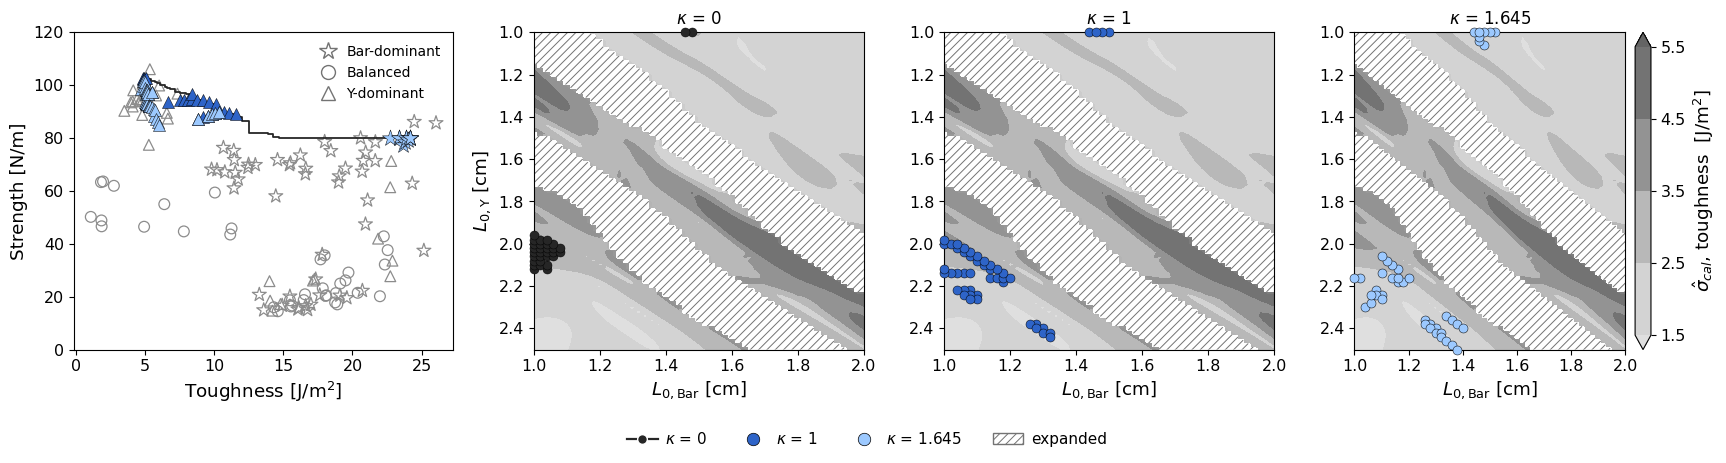

In [4]:
KCOL = {0.0: "0.15", 1.0: "#2E64C8", 1.645: "#9CC9FF"}
TYPE_MARKER = {"Bar-dominant": "*", "Balanced": "o", "Y-dominant": "^"}
MS = {"Bar-dominant": 150, "Balanced": 60, "Y-dominant": 75}
XL, YL = f"Toughness [{UNITS['Toughness']}]", f"Strength [{UNITS['Strength']}]"
P = {k: fronts[fronts.kappa == k] for k in KS}


def staircase(x, y):
    o = np.argsort(x); x, y = np.asarray(x)[o], np.asarray(y)[o]
    xs, ys = [x[0]], [y[0]]
    for i in range(1, len(x)):
        xs += [x[i - 1], x[i]]; ys += [y[i], y[i]]
    return np.array(xs), np.array(ys)


designs = pts.assign(type_name=pts.Class.map(mu.CLASS_NAMES))
SHAPE = GB.shape
FEAS = grid.feasible.to_numpy().reshape(SHAPE)
SIG_T = grid["sigma_cal_Toughness"].to_numpy().reshape(SHAPE)
LIGHT_GREYS = LinearSegmentedColormap.from_list("light_greys", plt.get_cmap("Greys")(np.linspace(0.22, 0.68, 256)))
LEVELS = np.arange(1.5, 5.6, 1.0)
HATCH = "////"

with mpl.rc_context({"font.size": 12, "axes.titlesize": 13.2, "axes.labelsize": 13.2, "xtick.labelsize": 11.4,
                     "ytick.labelsize": 11.4, "legend.fontsize": 11, "hatch.color": "0.45", "hatch.linewidth": 0.7}):
    fig, axes = plt.subplots(1, 4, figsize=(17.5, 4.3), gridspec_kw={"width_ratios": [1.15, 1, 1, 1]})
    ax = axes[0]
    for t, mk in TYPE_MARKER.items():
        d = designs[designs.type_name == t]
        ax.scatter(d.Toughness, d.Strength, marker=mk, s=110 if t == "Bar-dominant" else 60, facecolors="none",
                   edgecolors="0.55", linewidths=0.9, zorder=1)
    xs_, ys_ = staircase(P[0.0].mu_Toughness, P[0.0].mu_Strength)
    ax.plot(xs_, ys_, "-", c=KCOL[0.0], lw=1.3, zorder=2)
    for i, k in enumerate(KS[1:]):
        for t, mk in TYPE_MARKER.items():
            d = P[k][P[k].type_name == t]
            ax.scatter(d.mu_Toughness, d.mu_Strength, marker=mk, s=MS[t], c=[KCOL[k]], edgecolors="k", linewidths=0.35, zorder=3 + i)
    ax.set_xlabel(XL); ax.set_ylabel(YL); ax.set_ylim(0, 120)
    ax.legend(handles=[Line2D([], [], ls="", marker=mk, ms=13 if t == "Bar-dominant" else 10, mfc="none", mec="0.45", mew=1.0, label=t)
                       for t, mk in TYPE_MARKER.items()], loc="upper right", frameon=False, fontsize=10, handletextpad=0.3)
    for ax, k in zip(axes[1:], KS):
        ax.contourf(GB, GY, (~FEAS).astype(float), levels=[0.5, 1.5], colors="none", hatches=[HATCH], zorder=0)
        v = np.ma.masked_where(~FEAS, SIG_T)
        ax.pcolormesh(GB, GY, v, cmap=LIGHT_GREYS, norm=BoundaryNorm(LEVELS, LIGHT_GREYS.N, extend="both"), shading="nearest",
                      rasterized=True, zorder=0.5)
        m = ax.contourf(GB, GY, v, levels=LEVELS, cmap=LIGHT_GREYS, extend="both", zorder=1)
        ax.scatter(P[k].L0Bar, P[k].L0Y, s=42, c=[KCOL[k]], edgecolors="k", linewidths=0.35, zorder=3, clip_on=False)
        ax.set_xlabel("$L_{0,\\mathrm{Bar}}$ [cm]"); ax.set_xlim(mu.L_BAR_BOUNDS); ax.set_ylim(mu.L_Y_BOUNDS[1], mu.L_Y_BOUNDS[0])
        ax.set_title(f"$\\kappa$ = {k:g}", fontsize=12)
    axes[1].set_ylabel("$L_{0,\\mathrm{Y}}$ [cm]")
    cb = plt.colorbar(m, ax=axes[3], pad=0.03); cb.set_label(f"$\\hat\\sigma_{{cal}}$, toughness  [{UNITS['Toughness']}]")
    handles = [Line2D([], [], c=KCOL[0.0], lw=1.6, marker="o", ms=7, mec="w", label="$\\kappa$ = 0")]
    handles += [Line2D([], [], ls="", marker="o", ms=9, mfc=KCOL[k], mec="k", mew=0.5, label=f"$\\kappa$ = {k:g}") for k in KS[1:]]
    handles += [Patch(fc="white", ec="0.45", hatch=HATCH, label="expanded")]
    plt.tight_layout()
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.09), ncol=4, frameon=False, handletextpad=0.5, columnspacing=2.0)
    mu.save_figure(fig, "pareto_fronts"); plt.show()

## 4. Selected designs

The designs of each $P_\kappa$ with their predicted properties and calibrated uncertainties (`results/pareto_sets.csv` holds the full list).

In [5]:
cols = ["kappa", "L0Bar", "L0Y", "type_name", "mu_Strength", "sigma_cal_Strength", "mu_Toughness", "sigma_cal_Toughness"]
fronts[cols].groupby("kappa").head(5).round(2)

,kappa,L0Bar,L0Y,type_name,mu_Strength,sigma_cal_Strength,mu_Toughness,sigma_cal_Toughness
0,0.00,1.00,2.12,Y-dominant,102.80,4.62,5.11,2.06
1,0.00,1.04,2.12,Y-dominant,102.55,4.47,5.14,2.22
2,0.00,1.00,2.10,Y-dominant,102.28,5.53,5.41,2.65
3,0.00,1.02,2.10,Y-dominant,102.05,5.76,5.46,2.74
4,0.00,1.04,2.10,Y-dominant,101.59,6.00,5.56,2.84
31,1.00,1.06,2.14,Y-dominant,102.41,4.43,4.88,1.79
32,1.00,1.04,2.14,Y-dominant,102.54,4.65,4.89,1.73
33,1.00,1.02,2.14,Y-dominant,102.53,4.72,4.91,1.68
34,1.00,1.08,2.14,Y-dominant,102.04,3.99,4.92,1.86
35,1.00,1.00,2.14,Y-dominant,102.45,4.71,4.95,1.65


## Outputs

* `results/pareto_property_grid.csv` — predicted properties, uncertainties and configuration type on the 0.02 cm grid.
* `results/pareto_sets.csv`, `results/pareto_sets_summary.csv` — $P_\kappa$ for $\kappa = 0, 1, 1.645$.
* `figures/pareto_fronts.*` — property and design space (main text Fig. 5e–h).